# 32 — English benchmark alignment (canonical base)

This notebook defines the **authoritative English benchmark layer** for the project: what the English corpus is, how it is cleaned, how raw vendor labels map into the **project ontology** (`TARGET_9_CLASSES`), which classes are actually supported in data, and which **artifacts** downstream notebooks should consume.

**Role in the repo**

- **This notebook (32)** — benchmark *definition*: load, clean, map, coverage, splits, base eval slice, lightweight sanity outputs. It does **not** retrain models and is **not** the place for long-running English model comparisons.
- **`54_english_balanced_8class_eval.ipynb`** — **secondary** notebook that builds an evaluation-friendly (e.g. balanced / reduced-class) slice **on top of** the base benchmark here.

**Outputs (fixed locations)**

- Tables, JSON, and CSV summaries → `notebooks/results/english_dataset_alignment/`
- Figures → `figures/english_dataset_alignment/`
- Processed train/val/test and parquet → `data/processed/english_dataset_v1/`


In [1]:
# Canonical English benchmark — paths follow repo convention (results + figures under notebooks/figures roots).
# Install kagglehub on the fly if needed
try:
    import kagglehub
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install --quiet kagglehub
    import kagglehub

import json
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False

CWD = Path.cwd()
NOTEBOOK_DIR = CWD if CWD.name == "notebooks" else (CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
FIGURES_DIR = REPO_ROOT / "figures" / "english_dataset_alignment"
RESULTS_DIR = REPO_ROOT / "notebooks" / "results" / "english_dataset_alignment"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "english_dataset_v1"

for directory in [FIGURES_DIR, RESULTS_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Figures dir:", FIGURES_DIR)
print("Results dir:", RESULTS_DIR)
print("Processed dir:", PROCESSED_DIR)


/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
Figures dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/english_dataset_alignment
Results dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/english_dataset_alignment
Processed dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/english_dataset_v1


## Raw dataset loading

The English benchmark uses the Kaggle dataset **`rayyankauchali0/resume-dataset`** via `kagglehub`. The loader picks the first suitable `csv` / `jsonl` / `json` file under the download directory (unpacking zips if needed). **Columns** are detected flexibly (`Text` vs `Summary`, `Category`, `Location`, `Source`, etc.).


In [2]:
KAGGLE_HANDLE = "rayyankauchali0/resume-dataset"
download_path = Path(kagglehub.dataset_download(KAGGLE_HANDLE))
print("Downloaded to:", download_path)

def load_jsonl(path_obj: Path) -> pd.DataFrame:
    rows = []
    with path_obj.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_dataset(download_dir: Path) -> pd.DataFrame:
    candidates = list(download_dir.rglob("*.csv")) + list(download_dir.rglob("*.jsonl")) + list(download_dir.rglob("*.json"))
    if not candidates:
        for archive in download_dir.rglob("*.zip"):
            with zipfile.ZipFile(archive) as zf:
                extract_dir = archive.with_suffix("")
                zf.extractall(extract_dir)
        candidates = list(download_dir.rglob("*.csv")) + list(download_dir.rglob("*.jsonl")) + list(download_dir.rglob("*.json"))

    if not candidates:
        raise FileNotFoundError(f"No CSV/JSONL/JSON files found under {download_dir}")

    ranked = sorted(candidates, key=lambda p: (p.suffix != ".csv", len(str(p))))
    data_path = ranked[0]
    print("Using data file:", data_path)

    if data_path.suffix == ".csv":
        return pd.read_csv(data_path)
    if data_path.suffix == ".jsonl":
        return load_jsonl(data_path)
    return pd.read_json(data_path)

raw_df = load_dataset(download_path)
print("Shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
raw_df.head(3)


Downloaded to: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1
Using data file: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1/resumes_dataset.jsonl
Shape: (3500, 12)
Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 2014 102011 112013 092008 102011 ...,"City, State",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,Computer Science degree,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 30 70 30 40 ...,"City, State",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,Computer Science degree,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 2 052017 2 5 253 5 092021 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,ResumeAtlas


## Cleaning and row quality

Text is normalized (whitespace, control characters), empty or duplicate `(resume_text, raw_category)` pairs are removed, and very short documents (**fewer than 20 words**) are dropped. A short **cleaning summary** is written to **`32_english_cleaning_summary.csv`**.


In [3]:
TEXT_CANDIDATES = ["Resume_Text", "resume_text", "Resume", "Text", "Summary", "Experience", "Education", "Skills"]
CATEGORY_CANDIDATES = ["Category", "category", "Job_Role", "job_role"]
LOCATION_CANDIDATES = ["Location", "location", "City", "city", "Address", "address"]
SOURCE_CANDIDATES = ["Source", "source"]

def first_present(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None

resume_text_col = first_present(raw_df.columns, TEXT_CANDIDATES)
category_col = first_present(raw_df.columns, CATEGORY_CANDIDATES)
location_col = first_present(raw_df.columns, LOCATION_CANDIDATES)
source_col = first_present(raw_df.columns, SOURCE_CANDIDATES)

if resume_text_col is None or category_col is None:
    raise ValueError(f"Could not identify resume text/category columns. text={resume_text_col}, category={category_col}")

df = raw_df.copy()
df["resume_text"] = df[resume_text_col].fillna("").astype(str)
df["raw_category"] = df[category_col].fillna("").astype(str).str.strip()
df["raw_location"] = df[location_col].fillna("").astype(str) if location_col else ""
df["source"] = df[source_col].fillna("unknown").astype(str) if source_col else "unknown"

df["resume_text"] = (
    df["resume_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"\x00", " ", regex=True)
    .str.strip()
)

df = df[df["resume_text"] != ""].copy()
df = df[df["raw_category"] != ""].copy()
df = df.drop_duplicates(subset=["resume_text", "raw_category"]).reset_index(drop=True)

df["text_len_chars"] = df["resume_text"].str.len()
df["text_len_words"] = df["resume_text"].str.split().str.len()
df = df[df["text_len_words"] >= 20].copy()

cleaning_summary = pd.DataFrame([
    {
        "rows_after_cleaning": len(df),
        "unique_raw_categories": int(df["raw_category"].nunique()),
        "median_words": float(df["text_len_words"].median()) if len(df) else 0.0,
        "empty_source_share": float((df["source"].astype(str).str.strip() == "").mean()) if len(df) else 0.0,
    }
])
cleaning_summary.to_csv(RESULTS_DIR / "32_english_cleaning_summary.csv", index=False)
cleaning_summary


,rows_after_cleaning,unique_raw_categories,median_words,empty_source_share
0,3377,36,254.0,0.0


## Semantic mapping into the project ontology

Raw Kaggle **Category** strings are mapped to `supercategory` ∈ `TARGET_9_CLASSES` using:

1. A curated **`CATEGORY_TO_TARGET`** dictionary (reviewable, auditable mappings).
2. **`normalize_category`**: ordered keyword heuristics for common phrasing, then a **`generic_it_ops`** fallback.

`mapping_method` records which rule fired (`direct_map`, `keyword_*`, `fallback_generic`). Full row counts by raw label are exported to **`32_english_category_mapping_review.csv`**. The deduplicated label table is saved as **`label_to_supercategory_v1.csv`** under `PROCESSED_DIR`.


In [4]:
TARGET_9_CLASSES = [
    "backend_general_dev",
    "web_frontend",
    "sysadmin_devops_network",
    "project_product",
    "sales_account",
    "tech_support_helpdesk",
    "it_governance_leadership",
    "technical_specialized",
    "generic_it_ops",
]

CATEGORY_TO_TARGET = {
    "Java Developer": "backend_general_dev",
    "Python Developer": "backend_general_dev",
    "DotNet Developer": "backend_general_dev",
    "ETL Developer": "backend_general_dev",
    "SQL Developer": "backend_general_dev",
    "Software Developer": "backend_general_dev",
    "Backend Developer": "backend_general_dev",
    "Full Stack Developer": "backend_general_dev",
    "Blockchain Developer": "backend_general_dev",
    "Mobile Developer": "backend_general_dev",
    "React Developer": "web_frontend",
    "Frontend Developer": "web_frontend",
    "Web Designing": "web_frontend",
    "UI/UX Designer": "web_frontend",
    "Designer": "web_frontend",
    "Data Science": "technical_specialized",
    "Database": "technical_specialized",
    "AI Engineer": "technical_specialized",
    "Machine Learning Engineer": "technical_specialized",
    "Database Administrator": "technical_specialized",
    "SAP Developer": "technical_specialized",
    "Blockchain": "technical_specialized",
    "DevOps": "sysadmin_devops_network",
    "DevOps Engineer": "sysadmin_devops_network",
    "Cloud Engineer": "sysadmin_devops_network",
    "Network Security Engineer": "sysadmin_devops_network",
    "Cybersecurity Analyst": "sysadmin_devops_network",
    "Site Reliability Engineer": "sysadmin_devops_network",
    "System Administrator": "sysadmin_devops_network",
    "Business Analyst": "project_product",
    "Product Manager": "project_product",
    "PMO": "project_product",
    "Sales": "sales_account",
    "Advocate": "sales_account",
    "Testing": "tech_support_helpdesk",
    "QA Engineer": "tech_support_helpdesk",
    "Technical Lead": "it_governance_leadership",
    "Engineering Manager": "it_governance_leadership",
    "Operations Manager": "it_governance_leadership",
    "Principal Engineer": "it_governance_leadership",
    "Technical Writer": "generic_it_ops",
    "Digital Media": "generic_it_ops",
    "HR": "generic_it_ops",
    "Arts": "generic_it_ops",
}

def normalize_category(value: str):
    key = str(value).strip()
    if key in CATEGORY_TO_TARGET:
        return CATEGORY_TO_TARGET[key], "direct_map"

    lowered = key.lower()
    if any(token in lowered for token in ["frontend", "react", "ui", "ux", "web design", "designer"]):
        return "web_frontend", "keyword_frontend"
    if any(token in lowered for token in ["backend", "developer", "software", "programmer", "java", "python", "dotnet", "full stack", "mobile", "sql", "etl"]):
        return "backend_general_dev", "keyword_backend"
    if any(token in lowered for token in ["devops", "cloud", "sre", "site reliability", "system administrator", "sysadmin", "network", "security", "cyber", "infrastructure"]):
        return "sysadmin_devops_network", "keyword_infra"
    if any(token in lowered for token in ["product", "project", "business analyst", "pmo"]):
        return "project_product", "keyword_product"
    if any(token in lowered for token in ["sales", "account", "advocate", "customer success", "business development"]):
        return "sales_account", "keyword_sales"
    if any(token in lowered for token in ["support", "helpdesk", "qa", "testing", "test engineer"]):
        return "tech_support_helpdesk", "keyword_support"
    if any(token in lowered for token in ["manager", "director", "lead", "principal engineer", "head"]):
        return "it_governance_leadership", "keyword_leadership"
    if any(token in lowered for token in ["data", "database", "machine learning", "ai", "ml", "sap", "blockchain", "analyst"]):
        return "technical_specialized", "keyword_specialized"
    return "generic_it_ops", "fallback_generic"

normalized = df["raw_category"].apply(normalize_category)
df["supercategory"] = normalized.apply(lambda x: x[0])
df["mapping_method"] = normalized.apply(lambda x: x[1])

mapping_review = (
    df.groupby(["raw_category", "supercategory", "mapping_method"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["count", "raw_category"], ascending=[False, True])
)
method_summary = (
    df.groupby("mapping_method")
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
label_mapping_df = (
    df[["raw_category", "supercategory"]]
    .drop_duplicates()
    .rename(columns={"raw_category": "label"})
    .sort_values(["supercategory", "label"])
)

mapping_review.to_csv(RESULTS_DIR / "32_english_category_mapping_review.csv", index=False)
method_summary.to_csv(RESULTS_DIR / "32_english_mapping_method_summary.csv", index=False)
label_mapping_df.to_csv(PROCESSED_DIR / "label_to_supercategory_v1.csv", index=False)

print(df["supercategory"].value_counts())
display(method_summary)
display(mapping_review.head(30))


supercategory
backend_general_dev         1174
technical_specialized        678
sysadmin_devops_network      525
web_frontend                 415
tech_support_helpdesk        209
project_product              168
generic_it_ops               118
it_governance_leadership      90
Name: count, dtype: int64


,mapping_method,rows
0,direct_map,3377


,raw_category,supercategory,mapping_method,count
7,Data Science,technical_specialized,direct_map,189
23,Python Developer,backend_general_dev,direct_map,186
17,Java Developer,backend_general_dev,direct_map,185
27,SQL Developer,backend_general_dev,direct_map,171
10,DevOps,sysadmin_devops_network,direct_map,164
33,Testing,tech_support_helpdesk,direct_map,148
35,Web Designing,web_frontend,direct_map,146
4,Business Analyst,project_product,direct_map,143
8,Database,technical_specialized,direct_map,143
25,React Developer,web_frontend,direct_map,142


## Benchmark coverage vs project ontology

The nine `TARGET_9_CLASSES` entries define the **project ontology**. After mapping, we count how many **cleaned** rows fall into each class *before* dropping rare classes for stratified splitting.

- **Absent** classes have zero rows in the English corpus after cleaning and mapping (not evaluable as a native class here).
- **Weakly supported** classes have some rows but **below the split floor** (`min_rows_for_stratified_split`, currently aligned with the `>= 10` rule used when building `train/val/test`). They are excluded from the stratified splits to avoid unstable sampling; they remain documented in coverage for transparency.
- When absent or weak classes exist, treat English as a **reduced transfer benchmark** relative to the full 9-class ontology unless you explicitly construct a different slice (see notebook **54** for an evaluation-oriented variant).


In [5]:
# Coverage over the *full* cleaned/mapped corpus (`df`), independent of split filters
min_rows_for_stratified_split = 10

coverage_rows = []
for cls in TARGET_9_CLASSES:
    n = int((df["supercategory"] == cls).sum())
    coverage_rows.append({
        "ontology_class": cls,
        "n_rows_full_corpus": n,
        "present_in_corpus": n > 0,
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values("n_rows_full_corpus", ascending=False)
model_ready_mask = coverage_df["n_rows_full_corpus"] >= min_rows_for_stratified_split
coverage_df["meets_stratified_split_floor"] = model_ready_mask.values

weak_classes_df = coverage_df[
    coverage_df["present_in_corpus"] & ~coverage_df["meets_stratified_split_floor"]
].copy()
absent_classes_df = coverage_df[~coverage_df["present_in_corpus"]].copy()

coverage_df.to_csv(RESULTS_DIR / "32_english_benchmark_coverage_vs_ontology.csv", index=False)
weak_classes_df.to_csv(RESULTS_DIR / "32_english_weakly_supported_classes.csv", index=False)
absent_classes_df.to_csv(RESULTS_DIR / "32_english_absent_ontology_classes.csv", index=False)

ontology_classes_absent_in_english = absent_classes_df["ontology_class"].tolist()
ontology_classes_weak_in_english = weak_classes_df["ontology_class"].tolist()
classes_in_stratified_splits = coverage_df.loc[coverage_df["meets_stratified_split_floor"], "ontology_class"].tolist()

print(
    "Ontology classes absent in English (0 rows):",
    ontology_classes_absent_in_english or "(none)",
)
print(
    f"Weakly supported (0 < rows < {min_rows_for_stratified_split}):",
    ontology_classes_weak_in_english or "(none)",
)
print("Classes meeting stratified split floor:", len(classes_in_stratified_splits), "/", len(TARGET_9_CLASSES))
display(coverage_df)


Ontology classes absent in English (0 rows): ['sales_account']
Weakly supported (0 < rows < 10): (none)
Classes meeting stratified split floor: 8 / 9


,ontology_class,n_rows_full_corpus,present_in_corpus,meets_stratified_split_floor
0,backend_general_dev,1174,True,True
7,technical_specialized,678,True,True
2,sysadmin_devops_network,525,True,True
1,web_frontend,415,True,True
5,tech_support_helpdesk,209,True,True
3,project_product,168,True,True
8,generic_it_ops,118,True,True
6,it_governance_leadership,90,True,True
4,sales_account,0,False,False


## Location features, base English evaluation slice, and city-swap counterfactuals

Resume text is scanned for a **fixed set of city keywords** (see `CITY_PATTERN`). Rows with at least one match get a `source_city` (first mention) and feed **`32_english_base_eval_slice.csv`** — a **base** evaluation slice for English, not the balanced 8-class variant from notebook 54.

City **counterfactuals** duplicate texts with geographic mentions replaced by alternate cities (`SWAP_CITIES`), for robustness / geographic-shift probes. Downstream eval notebooks should load these CSVs from `RESULTS_DIR` rather than recomputing ad hoc.


In [6]:
CITY_PATTERN = re.compile(
    r"\b("
    r"new york|san francisco|los angeles|seattle|austin|chicago|boston|atlanta|dallas|houston|"
    r"london|berlin|paris|madrid|toronto|vancouver|sydney|melbourne|singapore|dubai|"
    r"bangalore|bengaluru|mumbai|delhi|hyderabad|pune"
    r")\b",
    flags=re.IGNORECASE,
)
SWAP_CITIES = ["new york", "san francisco", "london", "berlin", "singapore"]

def extract_city_mentions(text: str) -> list[str]:
    if not text:
        return []
    return sorted({m.group(0).lower() for m in CITY_PATTERN.finditer(text)})

def swap_cities_in_text(text: str, target_city: str) -> str:
    if not isinstance(text, str) or not text:
        return text

    def repl(match):
        original = match.group(0)
        if original.isupper():
            return target_city.upper()
        if original[:1].isupper():
            return target_city.title()
        return target_city.lower()

    return CITY_PATTERN.sub(repl, text)

df["city_mentions"] = df["resume_text"].apply(extract_city_mentions)
df["n_city_mentions"] = df["city_mentions"].apply(len)
df["has_city_mention"] = df["n_city_mentions"] > 0
df["source_city"] = df["city_mentions"].apply(lambda xs: xs[0] if xs else None)

location_summary = pd.DataFrame([{
    "rows_total": len(df),
    "rows_with_city_mentions": int(df["has_city_mention"].sum()),
    "share_with_city_mentions": float(df["has_city_mention"].mean()) if len(df) else 0.0,
    "median_words": float(df["text_len_words"].median()) if len(df) else 0.0,
}])
city_counts = (
    df.explode("city_mentions")
    .dropna(subset=["city_mentions"])
    .groupby("city_mentions")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

english_eval = df[df["source_city"].notna()].copy()
base_eval_df = english_eval[["resume_text", "supercategory", "raw_category", "source", "source_city"]].rename(columns={"supercategory": "label"})

counterfactual_rows = []
for _, row in english_eval.iterrows():
    for swap_city in SWAP_CITIES:
        if row["source_city"] == swap_city:
            continue
        counterfactual_rows.append({
            "row_id": int(row.name),
            "label": row["supercategory"],
            "raw_category": row["raw_category"],
            "source_city": row["source_city"],
            "swap_city": swap_city,
            "original_text": row["resume_text"],
            "swapped_text": swap_cities_in_text(row["resume_text"], swap_city),
        })

counterfactual_df = pd.DataFrame(counterfactual_rows)

location_summary.to_csv(RESULTS_DIR / "32_english_location_summary.csv", index=False)
city_counts.to_csv(RESULTS_DIR / "32_english_city_counts.csv", index=False)
base_eval_df.to_csv(RESULTS_DIR / "32_english_base_eval_slice.csv", index=False)
counterfactual_df.to_csv(RESULTS_DIR / "32_english_city_swap_counterfactuals.csv", index=False)

print("Base eval rows:", len(base_eval_df))
print("Counterfactual rows:", len(counterfactual_df))
display(location_summary)
display(city_counts.head(20))


Base eval rows: 1496
Counterfactual rows: 6792


,rows_total,rows_with_city_mentions,share_with_city_mentions,median_words
0,3377,1496,0.442997,254.0


,city_mentions,count
20,san francisco,780
17,new york,324
6,chicago,161
1,austin,134
13,los angeles,110
10,houston,107
5,boston,107
7,dallas,98
11,hyderabad,91
0,atlanta,69


## Stratified splits and processed artifacts

`model_df` keeps only supercategories with at least **`min_rows_for_stratified_split`** rows (defined in the coverage section above). **Train / validation / test** (70% / 15% / 15%) are stratified on `supercategory` and written to **`PROCESSED_DIR`**. The stacked table with a `split` column is saved as **`df_final.parquet`**.

**Downstream training notebooks** should treat these paths as the canonical English split artifacts from the benchmark-definition layer.


In [7]:
model_df = df[[
    "resume_text",
    "raw_category",
    "supercategory",
    "source",
    "raw_location",
    "source_city",
    "has_city_mention",
    "text_len_words",
    "mapping_method",
]].copy()
model_df = model_df.rename(columns={"raw_category": "label"})

class_counts = model_df["supercategory"].value_counts()
keep_classes = class_counts[class_counts >= min_rows_for_stratified_split].index
model_df = model_df[model_df["supercategory"].isin(keep_classes)].reset_index(drop=True)

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df["supercategory"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["supercategory"],
)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df.to_csv(PROCESSED_DIR / f"{split_name}.csv", index=False)

combined_df = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
], ignore_index=True)
combined_df.to_parquet(PROCESSED_DIR / "df_final.parquet", index=False)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_df)},
    {"split": "val", "rows": len(val_df)},
    {"split": "test", "rows": len(test_df)},
])
class_summary = (
    combined_df.groupby(["split", "supercategory"])
    .size()
    .reset_index(name="rows")
    .sort_values(["split", "rows"], ascending=[True, False])
)

split_summary.to_csv(RESULTS_DIR / "32_english_split_summary.csv", index=False)
class_summary.to_csv(RESULTS_DIR / "32_english_split_class_summary.csv", index=False)
combined_df.head(3)


,resume_text,label,supercategory,source,raw_location,source_city,has_city_mention,text_len_words,mapping_method,split
0,"═══ Kathryn Davis ═══ 📧 kathryn.davis@gmail.com | 📱 (780)280-8157x12901 | 📍 Millerhaven, AZ 💼 PROFILE Dedicated Mobile Developer with 3+ years of experience...",Mobile Developer,backend_general_dev,Synthetic,"Millerhaven, AZ",NaN,False,241,direct_map,train
1,"MATTHEW REED Email: matthew.reed@yahoo.com | Phone: (277)338-2646 | Location: Hoffmanstad, CO ==============================================================...",Cybersecurity Analyst,sysadmin_devops_network,Synthetic,"Hoffmanstad, CO",NaN,False,170,direct_map,train
2,chandan kumar personal info date birth 14041992 address prem nagar 999 new delhi 99999 india phone number 9999999999 email address hellokickresumecom web ww...,Web Designing,web_frontend,ResumeAtlas,"City, State",delhi,True,189,direct_map,train


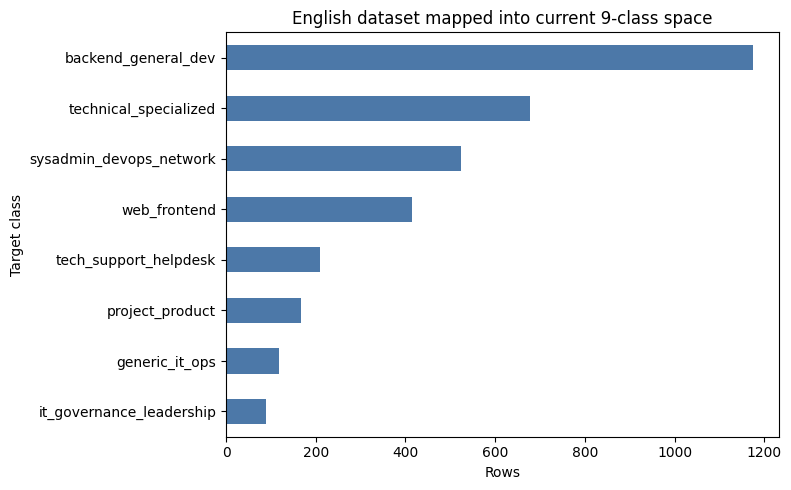

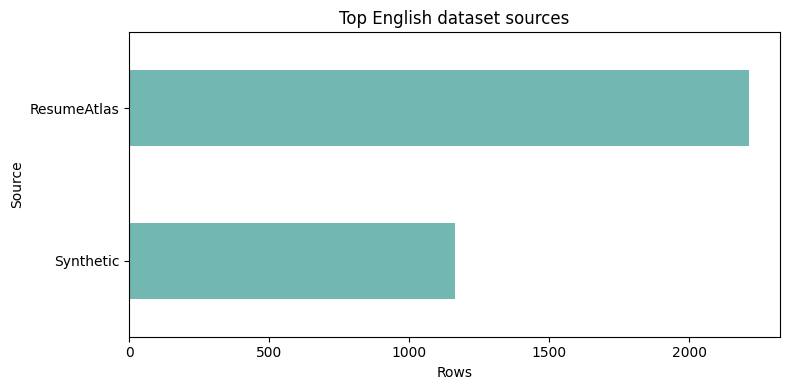

In [8]:
if HAS_MPL and not model_df.empty:
    class_counts = model_df["supercategory"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    class_counts.plot(kind="barh", ax=ax, color="#4c78a8")
    ax.set_title("English dataset mapped into current 9-class space")
    ax.set_xlabel("Rows")
    ax.set_ylabel("Target class")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "32_english_target9_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()

    source_counts = model_df["source"].astype(str).value_counts().head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    source_counts.sort_values().plot(kind="barh", ax=ax, color="#72b7b2")
    ax.set_title("Top English dataset sources")
    ax.set_xlabel("Rows")
    ax.set_ylabel("Source")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "32_english_source_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("matplotlib is not installed; skipping plots.")


In [9]:
benchmark_manifest = {
    "notebook": "32_english_dataset_alignment.ipynb",
    "role": "canonical_english_benchmark_definition",
    "ontology_target_classes": TARGET_9_CLASSES,
    "ontology_target_n_classes": len(TARGET_9_CLASSES),
    "min_rows_for_stratified_split": min_rows_for_stratified_split,
    "ontology_classes_absent_in_english": ontology_classes_absent_in_english,
    "ontology_classes_weak_in_english": ontology_classes_weak_in_english,
    "classes_in_stratified_splits": classes_in_stratified_splits,
    "secondary_eval_slice_notebook": "notebooks/54_english_balanced_8class_eval.ipynb",
    "transfer_setting_note": (
        "English is a reduced transfer setting relative to the full 9-class ontology when "
        "some classes are absent or too sparse for defensible multi-way evaluation; "
        "use notebook 54 for an evaluation-oriented balanced slice if needed."
    ),
    "directories": {
        "processed_dir": str(PROCESSED_DIR),
        "results_dir": str(RESULTS_DIR),
        "figures_dir": str(FIGURES_DIR),
    },
    "artifacts": {
        "train_csv": str(PROCESSED_DIR / "train.csv"),
        "val_csv": str(PROCESSED_DIR / "val.csv"),
        "test_csv": str(PROCESSED_DIR / "test.csv"),
        "df_final_parquet": str(PROCESSED_DIR / "df_final.parquet"),
        "label_to_supercategory": str(PROCESSED_DIR / "label_to_supercategory_v1.csv"),
        "cleaning_summary": str(RESULTS_DIR / "32_english_cleaning_summary.csv"),
        "mapping_review": str(RESULTS_DIR / "32_english_category_mapping_review.csv"),
        "mapping_method_summary": str(RESULTS_DIR / "32_english_mapping_method_summary.csv"),
        "benchmark_coverage": str(RESULTS_DIR / "32_english_benchmark_coverage_vs_ontology.csv"),
        "weak_classes": str(RESULTS_DIR / "32_english_weakly_supported_classes.csv"),
        "absent_classes": str(RESULTS_DIR / "32_english_absent_ontology_classes.csv"),
        "split_summary": str(RESULTS_DIR / "32_english_split_summary.csv"),
        "split_class_summary": str(RESULTS_DIR / "32_english_split_class_summary.csv"),
        "location_summary": str(RESULTS_DIR / "32_english_location_summary.csv"),
        "city_counts": str(RESULTS_DIR / "32_english_city_counts.csv"),
        "base_eval_slice": str(RESULTS_DIR / "32_english_base_eval_slice.csv"),
        "city_swap_counterfactuals": str(RESULTS_DIR / "32_english_city_swap_counterfactuals.csv"),
        "quick_answer": str(RESULTS_DIR / "32_english_quick_answer.json"),
        "manifest": str(RESULTS_DIR / "32_english_benchmark_manifest.json"),
        "figure_target9_distribution": str(FIGURES_DIR / "32_english_target9_distribution.png"),
        "figure_source_distribution": str(FIGURES_DIR / "32_english_source_distribution.png"),
    },
}

(RESULTS_DIR / "32_english_benchmark_manifest.json").write_text(
    json.dumps(benchmark_manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

quick_answer = {
    "notebook_role": "canonical_english_benchmark_definition",
    "dataset_ready_for_next_step": True,
    "recommended_next_move": (
        "Consume splits and parquet from processed_dir; use base_eval_slice and city_swap "
        "counterfactuals from results_dir for English probes. Run heavy model comparisons "
        "in dedicated eval notebooks (not 32). See secondary_eval_slice_notebook."
    ),
    "secondary_eval_slice_notebook": "notebooks/54_english_balanced_8class_eval.ipynb",
    "processed_dir": str(PROCESSED_DIR),
    "results_dir": str(RESULTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "ontology_target_n_classes": len(TARGET_9_CLASSES),
    "n_ontology_classes_present_in_corpus": int(coverage_df["present_in_corpus"].sum()),
    "n_classes_meeting_stratified_split_floor": len(classes_in_stratified_splits),
    "ontology_classes_absent_in_english": ontology_classes_absent_in_english,
    "ontology_classes_weak_in_english": ontology_classes_weak_in_english,
    "min_rows_for_stratified_split": min_rows_for_stratified_split,
    "transfer_setting_note": benchmark_manifest["transfer_setting_note"],
    "n_rows_clean": int(len(df)),
    "n_rows_model_ready": int(len(model_df)),
    "n_rows_base_eval": int(len(base_eval_df)),
    "n_rows_counterfactual": int(len(counterfactual_df)),
    "benchmark_manifest": str(RESULTS_DIR / "32_english_benchmark_manifest.json"),
}

(RESULTS_DIR / "32_english_quick_answer.json").write_text(
    json.dumps(quick_answer, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(json.dumps(quick_answer, indent=2, ensure_ascii=False))


{
  "notebook_role": "canonical_english_benchmark_definition",
  "dataset_ready_for_next_step": true,
  "recommended_next_move": "Consume splits and parquet from processed_dir; use base_eval_slice and city_swap counterfactuals from results_dir for English probes. Run heavy model comparisons in dedicated eval notebooks (not 32). See secondary_eval_slice_notebook.",
  "secondary_eval_slice_notebook": "notebooks/54_english_balanced_8class_eval.ipynb",
  "processed_dir": "/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/english_dataset_v1",
  "results_dir": "/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/english_dataset_alignment",
  "figures_dir": "/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/english_dataset_alignment",
  "ontology_target_n_classes": 9,
  "n_ontology_classes_present_in_corpus": 8,
  "n_classes_meeting_stratified_split_floor": 8,
  "ontology_classes_absent_in_english": [
  

## Key takeaways

- **What 32 is.** The single **canonical English benchmark-definition** notebook: it loads the Kaggle English resume corpus, cleans it, maps labels into the **nine-class project ontology**, measures **coverage** (absent / weak / split-eligible classes), writes **processed splits** and **base** evaluation/counterfactual CSVs, and records everything under `notebooks/results/english_dataset_alignment/`, `figures/english_dataset_alignment/`, and `data/processed/english_dataset_v1/`.

- **How complete the benchmark is.** Completeness is **not** “all nine classes are equally represented,” but “the ontology is the target space and the data reveal which dimensions are **actually supported**.” Consult **`32_english_benchmark_coverage_vs_ontology.csv`**, plus **`32_english_absent_ontology_classes.csv`** and **`32_english_weakly_supported_classes.csv`**, before claiming a full 9-way English benchmark.

- **Limitations.** If some ontology classes are **missing** or **too rare** for stable splits, English should be read as a **reduced transfer setting** for the project’s label space—not as proof of native 9-class parity. Notebook **54** may build a **more evaluation-friendly** (e.g. balanced 8-class) slice **on top of** this base; treat **32** as ground truth for “what the dataset is,” and **54** as an optional eval-focused adjustment.

- **Why treat 32 as canonical.** Downstream work should **consume the manifest** (**`32_english_benchmark_manifest.json`**) and the listed artifacts rather than re-deriving paths, mappings, or splits—so English results stay **comparable** and **auditable** across notebooks.
